In [12]:
# Cell 1 — imports
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
BASE = Path.cwd().parent / "graphlaplacianoptimizer" / "energy_results"


In [14]:
# Cell 2 — paths


METRICS_PATH = BASE / "metrics.parquet"
LAMBDAS_PATH = BASE / "lambdas.pkl"
PARAMS_PATH = BASE / "params.json"
CONFIG_PATH = BASE / "experiment_config.json"

In [15]:
# Cell 3 — load config + params
with open(CONFIG_PATH) as f:
    config = json.load(f)

with open(PARAMS_PATH) as f:
    params = pd.DataFrame(json.load(f))

print("Config:")
print(config)
print("\nParams:")
display(params)

Config:
{'sample_sizes': [100, 500, 2000, 8000, 30000, 100000], 'seeds': [55, 23, 43], 'n_trials': 5}

Params:


,trial,eps,k,topk,p,sigma
0,0,46.314987,23,264,2.745476,0.727631
1,1,4.764177,13,469,5.482894,0.840485
2,2,9.218009,24,228,3.462868,0.903809
3,3,9.064765,17,486,1.786486,0.433414
4,4,8.202861,28,263,2.698821,0.730239


In [16]:
# Cell 4 — load metrics with fallback from lambdas.pkl
try:
    metrics = pd.read_parquet(METRICS_PATH).reset_index()
    print("Loaded metrics.parquet")
except Exception as e:
    print("Could not read metrics.parquet, rebuilding metrics from lambdas.pkl")
    print("Reason:", e)

    with open(LAMBDAS_PATH, "rb") as f:
        lambda_records = pickle.load(f)

    metrics = pd.DataFrame([
        {
            "trial": r["trial"],
            "sample_size": r["sample_size"],
            "seed": r["seed"],
            "Total Energy": float(np.sum(r["lambdas"])),
            "Mean Energy": float(np.mean(r["lambdas"])),
            "Variance Energy": float(np.var(r["lambdas"])),
        }
        for r in lambda_records
    ])

metrics = metrics.sort_values(["trial", "seed", "sample_size"]).reset_index(drop=True)
display(metrics.head())
print(metrics.shape)

Loaded metrics.parquet


,trial,sample_size,seed,Total Energy,Mean Energy,Variance Energy
0,0,100,23,17.873662,0.178737,0.051676
1,0,500,23,63.368663,0.126737,0.028196
2,0,2000,23,243.624632,0.121812,0.024736
3,0,8000,23,1115.464609,0.139433,0.031537
4,0,30000,23,3121.337737,0.104045,0.017671


(90, 6)


In [17]:
# Cell 5 — join params for easier analysis
metrics_full = metrics.merge(params, on="trial", how="left")
display(metrics_full.head())

,trial,sample_size,seed,Total Energy,Mean Energy,Variance Energy,eps,k,topk,p,sigma
0,0,100,23,17.873662,0.178737,0.051676,46.314987,23,264,2.745476,0.727631
1,0,500,23,63.368663,0.126737,0.028196,46.314987,23,264,2.745476,0.727631
2,0,2000,23,243.624632,0.121812,0.024736,46.314987,23,264,2.745476,0.727631
3,0,8000,23,1115.464609,0.139433,0.031537,46.314987,23,264,2.745476,0.727631
4,0,30000,23,3121.337737,0.104045,0.017671,46.314987,23,264,2.745476,0.727631


In [18]:
# Cell 6 — aggregated summary by sample size
summary = (
    metrics_full
    .groupby("sample_size")
    .agg(
        total_mean=("Total Energy", "mean"),
        total_std=("Total Energy", "std"),
        mean_mean=("Mean Energy", "mean"),
        mean_std=("Mean Energy", "std"),
        var_mean=("Variance Energy", "mean"),
        var_std=("Variance Energy", "std"),
    )
    .reset_index()
)

summary["var_pct_change_vs_prev"] = summary["var_mean"].pct_change() * 100
summary["mean_pct_change_vs_prev"] = summary["mean_mean"].pct_change() * 100

display(summary)

,sample_size,total_mean,total_std,mean_mean,mean_std,var_mean,var_std,var_pct_change_vs_prev,mean_pct_change_vs_prev
0,100,17.860533,3.073514,0.178605,0.030735,0.051283,0.008233,NaN,NaN
1,500,74.918972,8.672515,0.149838,0.017345,0.039345,0.008472,-23.278636,-16.106676
2,2000,261.094562,16.198366,0.130547,0.008099,0.027751,0.003308,-29.466845,-12.874351
3,8000,1058.978575,53.011440,0.132372,0.006626,0.028509,0.003166,2.730462,1.397992
4,30000,3465.739781,256.946359,0.115525,0.008565,0.021890,0.003161,-23.219450,-12.727481
5,100000,11128.875516,491.814688,0.111289,0.004918,0.020172,0.001906,-7.845594,-3.666667


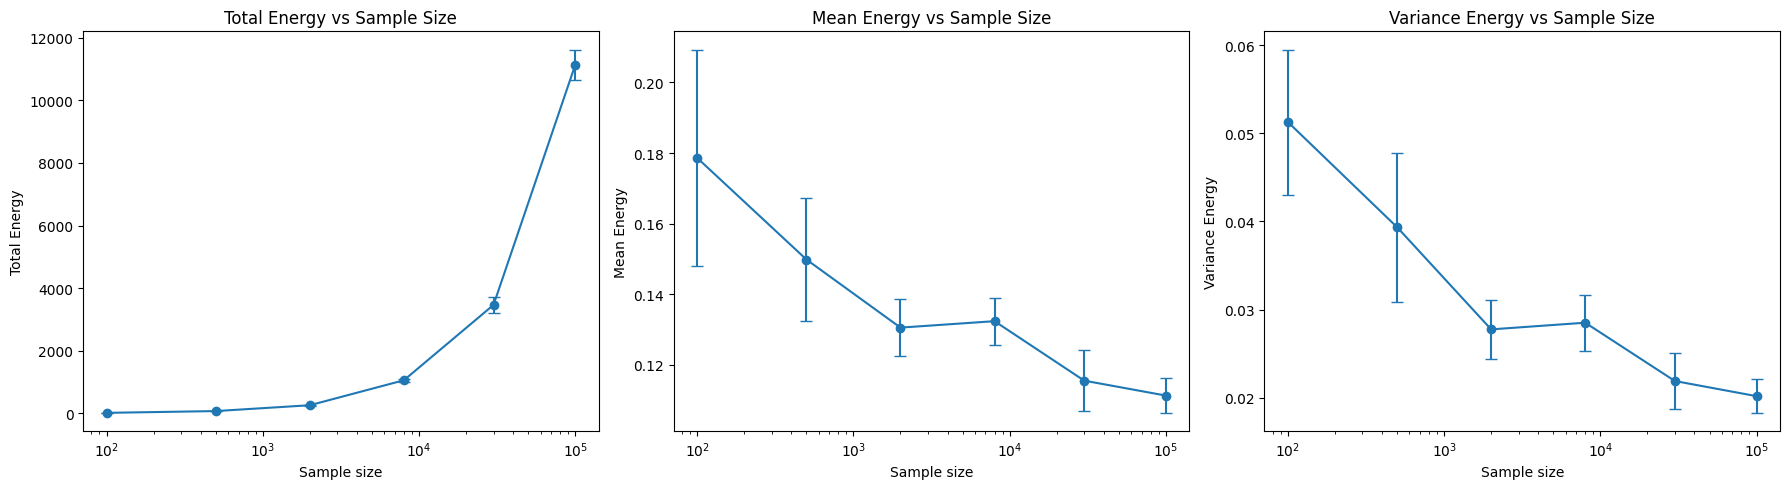

In [19]:
# Cell 7 — plot total / mean / variance vs sample size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].errorbar(
    summary["sample_size"], summary["total_mean"], yerr=summary["total_std"],
    marker="o", capsize=4
)
axes[0].set_xscale("log")
axes[0].set_title("Total Energy vs Sample Size")
axes[0].set_xlabel("Sample size")
axes[0].set_ylabel("Total Energy")

axes[1].errorbar(
    summary["sample_size"], summary["mean_mean"], yerr=summary["mean_std"],
    marker="o", capsize=4
)
axes[1].set_xscale("log")
axes[1].set_title("Mean Energy vs Sample Size")
axes[1].set_xlabel("Sample size")
axes[1].set_ylabel("Mean Energy")

axes[2].errorbar(
    summary["sample_size"], summary["var_mean"], yerr=summary["var_std"],
    marker="o", capsize=4
)
axes[2].set_xscale("log")
axes[2].set_title("Variance Energy vs Sample Size")
axes[2].set_xlabel("Sample size")
axes[2].set_ylabel("Variance Energy")

plt.tight_layout()
plt.show()

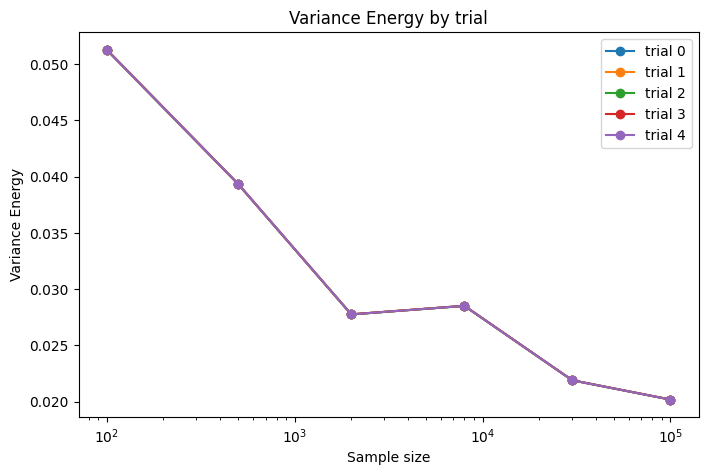

In [20]:
# Cell 8 — per-trial variance curves
plt.figure(figsize=(8, 5))

for trial_id, g in metrics_full.groupby("trial"):
    tmp = g.groupby("sample_size")["Variance Energy"].mean().reset_index()
    plt.plot(tmp["sample_size"], tmp["Variance Energy"], marker="o", label=f"trial {trial_id}")

plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("Variance Energy")
plt.title("Variance Energy by trial")
plt.legend()
plt.show()

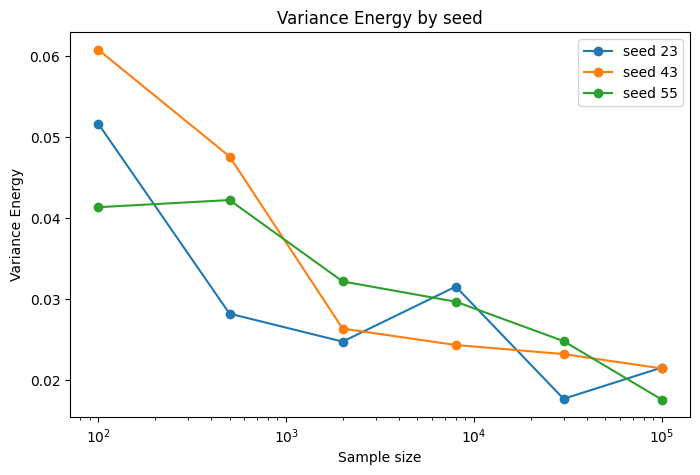

In [21]:
# Cell 9 — per-seed variance curves
plt.figure(figsize=(8, 5))

for seed, g in metrics_full.groupby("seed"):
    tmp = g.groupby("sample_size")["Variance Energy"].mean().reset_index()
    plt.plot(tmp["sample_size"], tmp["Variance Energy"], marker="o", label=f"seed {seed}")

plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("Variance Energy")
plt.title("Variance Energy by seed")
plt.legend()
plt.show()

In [22]:
# Cell 10 — quantify trial sensitivity vs seed sensitivity
trial_sensitivity = (
    metrics_full
    .groupby(["sample_size", "seed"])["Variance Energy"]
    .std()
    .reset_index(name="std_across_trials")
)

seed_sensitivity = (
    metrics_full
    .groupby(["sample_size", "trial"])["Variance Energy"]
    .std()
    .reset_index(name="std_across_seeds")
)

print("Std of Variance Energy across trials (fixed size, seed):")
display(trial_sensitivity)

print("Std of Variance Energy across seeds (fixed size, trial):")
display(seed_sensitivity)

print("Average std across trials:", trial_sensitivity["std_across_trials"].mean())
print("Max std across trials:", trial_sensitivity["std_across_trials"].max())

print("Average std across seeds:", seed_sensitivity["std_across_seeds"].mean())
print("Max std across seeds:", seed_sensitivity["std_across_seeds"].max())

Std of Variance Energy across trials (fixed size, seed):


,sample_size,seed,std_across_trials
0,100,23,0.000011
1,100,43,0.000024
2,100,55,0.000007
3,500,23,0.000004
4,500,43,0.000016
5,500,55,0.000004
6,2000,23,0.000001
7,2000,43,0.000002
8,2000,55,0.000005
9,8000,23,0.000010


Std of Variance Energy across seeds (fixed size, trial):


,sample_size,trial,std_across_seeds
0,100,0,0.009736
1,100,1,0.009747
2,100,2,0.009730
3,100,3,0.009754
4,100,4,0.009737
5,500,0,0.010024
6,500,1,0.010030
7,500,2,0.010017
8,500,3,0.010026
9,500,4,0.010023


Average std across trials: 6.203237039415839e-06
Max std across trials: 2.376370334500675e-05
Average std across seeds: 0.005570052340229571
Max std across seeds: 0.010029949937209286


In [23]:
# Cell 11 — automatic text conclusions
def draw_conclusions(summary_df, trial_sens_df, seed_sens_df):
    s = summary_df.copy().sort_values("sample_size")

    n0 = int(s.iloc[0]["sample_size"])
    n1 = int(s.iloc[-1]["sample_size"])

    mean0 = s.iloc[0]["mean_mean"]
    mean1 = s.iloc[-1]["mean_mean"]

    var0 = s.iloc[0]["var_mean"]
    var1 = s.iloc[-1]["var_mean"]

    var30k = float(s.loc[s["sample_size"] == 30000, "var_mean"].iloc[0]) if (s["sample_size"] == 30000).any() else None
    var100k = float(s.loc[s["sample_size"] == 100000, "var_mean"].iloc[0]) if (s["sample_size"] == 100000).any() else None

    avg_trial_std = trial_sens_df["std_across_trials"].mean()
    max_trial_std = trial_sens_df["std_across_trials"].max()

    avg_seed_std = seed_sens_df["std_across_seeds"].mean()
    max_seed_std = seed_sens_df["std_across_seeds"].max()

    print("Conclusions")
    print("-----------")
    print(f"1. Total Energy increases strongly with sample size, so it is not plateauing in absolute scale.")
    print(f"2. Mean Energy decreases from {mean0:.4f} at n={n0} to {mean1:.4f} at n={n1}.")
    print(f"3. Variance Energy decreases from {var0:.4f} at n={n0} to {var1:.4f} at n={n1}.")
    if var30k is not None and var100k is not None:
        pct = 100 * (var100k - var30k) / var30k
        print(f"4. From n=30000 to n=100000, Variance Energy changes from {var30k:.5f} to {var100k:.5f} ({pct:.2f}%).")
        print("   This suggests a practical plateau or near-plateau starting around 30000.")
    print(f"5. Parameter sensitivity is tiny: avg std across trials = {avg_trial_std:.8f}, max = {max_trial_std:.8f}.")
    print(f"6. Seed sensitivity is much larger: avg std across seeds = {avg_seed_std:.6f}, max = {max_seed_std:.6f}.")
    print("7. So, in this experiment, sample size and bootstrap draw matter much more than the tested ArrowSpace parameters.")

draw_conclusions(summary, trial_sensitivity, seed_sensitivity)

Conclusions
-----------
1. Total Energy increases strongly with sample size, so it is not plateauing in absolute scale.
2. Mean Energy decreases from 0.1786 at n=100 to 0.1113 at n=100000.
3. Variance Energy decreases from 0.0513 at n=100 to 0.0202 at n=100000.
4. From n=30000 to n=100000, Variance Energy changes from 0.02189 to 0.02017 (-7.85%).
   This suggests a practical plateau or near-plateau starting around 30000.
5. Parameter sensitivity is tiny: avg std across trials = 0.00000620, max = 0.00002376.
6. Seed sensitivity is much larger: avg std across seeds = 0.005570, max = 0.010030.
7. So, in this experiment, sample size and bootstrap draw matter much more than the tested ArrowSpace parameters.


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# metrics_full is assumed to exist already
# columns: trial, sample_size, seed, Variance Energy, ...

# 1) Collapse trials first: independent unit = seed
seed_level = (
    metrics_full
    .groupby(["sample_size", "seed"], as_index=False)["Variance Energy"]
    .mean()
    .sort_values(["sample_size", "seed"])
)

display(seed_level)

# 2) Conservative summary over seeds
# n_seeds = 3 -> t critical for 95% CI with df=2
T_CRIT_95_DF2 = 4.303

cons_summary = (
    seed_level
    .groupby("sample_size")
    .agg(
        mean_var=("Variance Energy", "mean"),
        sd_var=("Variance Energy", "std"),
        n=("Variance Energy", "count"),
        min_var=("Variance Energy", "min"),
        max_var=("Variance Energy", "max"),
    )
    .reset_index()
)

cons_summary["se"] = cons_summary["sd_var"] / np.sqrt(cons_summary["n"])
cons_summary["ci_low"] = cons_summary["mean_var"] - T_CRIT_95_DF2 * cons_summary["se"]
cons_summary["ci_high"] = cons_summary["mean_var"] + T_CRIT_95_DF2 * cons_summary["se"]

# 3) Relative changes between consecutive sample sizes
cons_summary["abs_change_vs_prev"] = cons_summary["mean_var"].diff()
cons_summary["rel_change_vs_prev_pct"] = cons_summary["mean_var"].pct_change() * 100

display(cons_summary)

,sample_size,seed,Variance Energy
0,100,23,0.051681
1,100,43,0.060819
2,100,55,0.041350
3,500,23,0.028195
4,500,43,0.047610
5,500,55,0.042230
6,2000,23,0.024737
7,2000,43,0.026343
8,2000,55,0.032175
9,8000,23,0.031537


,sample_size,mean_var,sd_var,n,min_var,max_var,se,ci_low,ci_high,abs_change_vs_prev,rel_change_vs_prev_pct
0,100,0.051283,0.009741,3,0.041350,0.060819,0.005624,0.027084,0.075483,NaN,NaN
1,500,0.039345,0.010024,3,0.028195,0.047610,0.005787,0.014443,0.064248,-0.011938,-23.278636
2,2000,0.027751,0.003914,3,0.024737,0.032175,0.002260,0.018028,0.037475,-0.011594,-29.466845
3,8000,0.028509,0.003746,3,0.024320,0.031537,0.002163,0.019202,0.037816,0.000758,2.730462
4,30000,0.021890,0.003741,3,0.017670,0.024800,0.002160,0.012597,0.031183,-0.006620,-23.219450
5,100000,0.020172,0.002255,3,0.017569,0.021531,0.001302,0.014570,0.025774,-0.001717,-7.845594


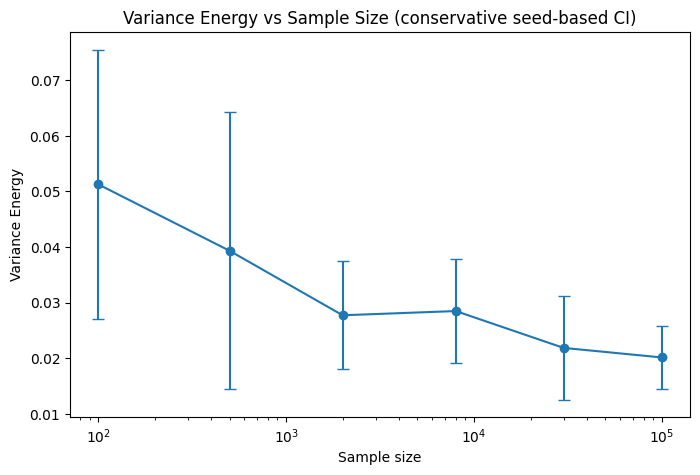

In [25]:
# 4) Plot using only seed-based uncertainty
plt.figure(figsize=(8, 5))
plt.errorbar(
    cons_summary["sample_size"],
    cons_summary["mean_var"],
    yerr=T_CRIT_95_DF2 * cons_summary["se"],
    marker="o",
    capsize=4
)
plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("Variance Energy")
plt.title("Variance Energy vs Sample Size (conservative seed-based CI)")
plt.show()

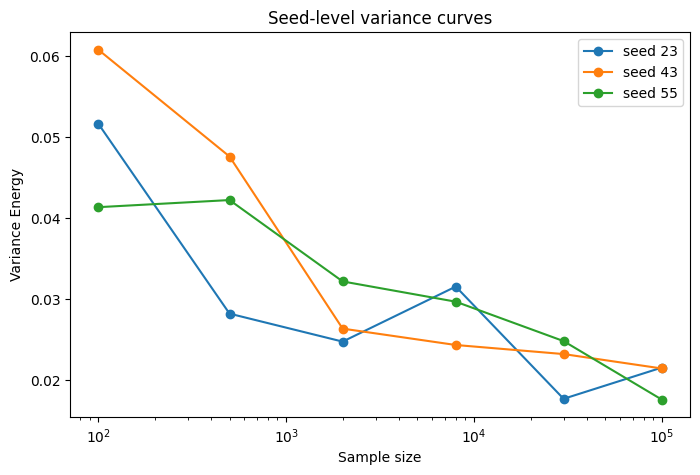

In [26]:
# 5) Seed-level curves: this is the key diagnostic
plt.figure(figsize=(8, 5))
for seed, g in seed_level.groupby("seed"):
    plt.plot(
        g["sample_size"],
        g["Variance Energy"],
        marker="o",
        label=f"seed {seed}"
    )

plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("Variance Energy")
plt.title("Seed-level variance curves")
plt.legend()
plt.show()

In [27]:
# 6) Pairwise interpretation table
pairwise = cons_summary[["sample_size", "mean_var", "ci_low", "ci_high"]].copy()
pairwise["next_sample_size"] = pairwise["sample_size"].shift(-1)
pairwise["next_mean_var"] = pairwise["mean_var"].shift(-1)
pairwise["next_ci_low"] = pairwise["ci_low"].shift(-1)
pairwise["next_ci_high"] = pairwise["ci_high"].shift(-1)

pairwise = pairwise.iloc[:-1].copy()

pairwise["abs_change"] = pairwise["next_mean_var"] - pairwise["mean_var"]
pairwise["rel_change_pct"] = 100 * pairwise["abs_change"] / pairwise["mean_var"]

# CI overlap heuristic (not a formal proof, but conservative)
pairwise["ci_overlap"] = ~(
    (pairwise["ci_high"] < pairwise["next_ci_low"]) |
    (pairwise["next_ci_high"] < pairwise["ci_low"])
)

display(pairwise)

,sample_size,mean_var,ci_low,ci_high,next_sample_size,next_mean_var,next_ci_low,next_ci_high,abs_change,rel_change_pct,ci_overlap
0,100,0.051283,0.027084,0.075483,500.0,0.039345,0.014443,0.064248,-0.011938,-23.278636,True
1,500,0.039345,0.014443,0.064248,2000.0,0.027751,0.018028,0.037475,-0.011594,-29.466845,True
2,2000,0.027751,0.018028,0.037475,8000.0,0.028509,0.019202,0.037816,0.000758,2.730462,True
3,8000,0.028509,0.019202,0.037816,30000.0,0.021890,0.012597,0.031183,-0.006620,-23.219450,True
4,30000,0.021890,0.012597,0.031183,100000.0,0.020172,0.014570,0.025774,-0.001717,-7.845594,True


In [28]:
# 7) A practical plateau heuristic
# You can tune the threshold. Here: less than 10% relative change and overlapping CIs.
PLATEAU_THRESHOLD_PCT = 10

pairwise["practical_plateau_step"] = (
    pairwise["rel_change_pct"].abs() <= PLATEAU_THRESHOLD_PCT
) & pairwise["ci_overlap"]

display(pairwise[[
    "sample_size",
    "next_sample_size",
    "rel_change_pct",
    "ci_overlap",
    "practical_plateau_step"
]])

,sample_size,next_sample_size,rel_change_pct,ci_overlap,practical_plateau_step
0,100,500.0,-23.278636,True,False
1,500,2000.0,-29.466845,True,False
2,2000,8000.0,2.730462,True,True
3,8000,30000.0,-23.219450,True,False
4,30000,100000.0,-7.845594,True,True


In [29]:
# 8) Automatic conservative conclusion
last_step = pairwise.iloc[-1]

print("Conservative conclusion")
print("----------------------")
print("Independent unit used: seed (not trial).")
print()

for _, row in pairwise.iterrows():
    print(
        f"{int(row['sample_size'])} -> {int(row['next_sample_size'])}: "
        f"relative change = {row['rel_change_pct']:.2f}%, "
        f"CI overlap = {row['ci_overlap']}"
    )

print()
if last_step["practical_plateau_step"]:
    print(
        f"Between {int(last_step['sample_size'])} and {int(last_step['next_sample_size'])}, "
        "the change is small enough to be consistent with a practical plateau."
    )
else:
    print(
        f"Between {int(last_step['sample_size'])} and {int(last_step['next_sample_size'])}, "
        "the evidence is not strong enough to claim a practical plateau."
    )

print()
print("Recommended wording:")
print(
    "The data support decreasing variance with diminishing returns at larger sample sizes, "
    "but do not provide strong evidence of a strict plateau."
)

Conservative conclusion
----------------------
Independent unit used: seed (not trial).

100 -> 500: relative change = -23.28%, CI overlap = True
500 -> 2000: relative change = -29.47%, CI overlap = True
2000 -> 8000: relative change = 2.73%, CI overlap = True
8000 -> 30000: relative change = -23.22%, CI overlap = True
30000 -> 100000: relative change = -7.85%, CI overlap = True

Between 30000 and 100000, the change is small enough to be consistent with a practical plateau.

Recommended wording:
The data support decreasing variance with diminishing returns at larger sample sizes, but do not provide strong evidence of a strict plateau.
